In [1]:
import pandas as pd

In [2]:
import unicodedata
import re
from unidecode import unidecode

def normalize_name(name):

    name = name.lower()

    name = unidecode(name)

    name = re.sub(r'[^\w\s]', '', name) 
    name = re.sub(r'\s+', ' ', name).strip()  
    
    replacements = {
        'jr': '', 'sr': '', 'dr': '', 'lic': '', 'ing': '', 
        'mtro': '', 'phd': '', 'c': '', 's a': '', 's.a.': ''
    }
    
    for k, v in replacements.items():
        name = name.replace(k, v)
    
    return name








In [3]:
df = pd.read_json('data/openalex_authors_complete.json')

In [4]:
df=df.T
df.head()

,id,orcid,display_name,display_name_alternatives,works_count,cited_by_count,summary_stats,ids,affiliations,last_known_institutions,topics,topic_share,x_concepts,counts_by_year,works_api_url,updated_date,created_date
A5001442172,https://openalex.org/A5001442172,https://orcid.org/0000-0001-5336-7744,Roxana Sobrino Triana,"[Roxana Sobrino, Roxana Sobrino Triana]",14,20,"{'2yr_mean_citedness': 0.0, 'h_index': 3, 'i10...",{'openalex': 'https://openalex.org/A5001442172...,[{'institution': {'id': 'https://openalex.org/...,"[{'id': 'https://openalex.org/I4432739', 'ror'...","[{'id': 'https://openalex.org/T12341', 'displa...","[{'id': 'https://openalex.org/T12341', 'displa...","[{'id': 'https://openalex.org/C142362112', 'wi...","[{'year': 2025, 'works_count': 1, 'cited_by_co...",https://api.openalex.org/works?filter=author.i...,2025-07-05T02:34:00.814341,2023-07-21
A5086708085,https://openalex.org/A5086708085,https://orcid.org/0000-0001-5824-6415,David E. Williams,"[D. E. Williams, David Williams, D. Williams, ...",376,17232,"{'2yr_mean_citedness': 1.941176470588235, 'h_i...",{'openalex': 'https://openalex.org/A5086708085...,[{'institution': {'id': 'https://openalex.org/...,"[{'id': 'https://openalex.org/I141945490', 'ro...","[{'id': 'https://openalex.org/T10252', 'displa...","[{'id': 'https://openalex.org/T11340', 'displa...","[{'id': 'https://openalex.org/C86803240', 'wik...","[{'year': 2025, 'works_count': 1, 'cited_by_co...",https://api.openalex.org/works?filter=author.i...,2025-07-08T23:16:15.725665,2023-07-21
A5017904400,https://openalex.org/A5017904400,https://orcid.org/0000-0003-0331-1413,Simoni Campos Dias,"[Sarah Dias, Simoni C. Dias, Simoni Campos Dia...",103,3083,"{'2yr_mean_citedness': 3.0, 'h_index': 29, 'i1...",{'openalex': 'https://openalex.org/A5017904400...,[{'institution': {'id': 'https://openalex.org/...,"[{'id': 'https://openalex.org/I24871856', 'ror...","[{'id': 'https://openalex.org/T11103', 'displa...","[{'id': 'https://openalex.org/T11103', 'displa...","[{'id': 'https://openalex.org/C86803240', 'wik...","[{'year': 2025, 'works_count': 3, 'cited_by_co...",https://api.openalex.org/works?filter=author.i...,2025-07-08T20:14:32.664231,2023-07-21
A5067766228,https://openalex.org/A5067766228,https://orcid.org/0000-0001-7029-6407,Uwe Kappelmeyer,"[Uwe Kappelmeyer, U. Kappelmeyer]",52,2977,"{'2yr_mean_citedness': 8.5, 'h_index': 21, 'i1...",{'openalex': 'https://openalex.org/A5067766228...,[{'institution': {'id': 'https://openalex.org/...,"[{'id': 'https://openalex.org/I137479271', 'ro...","[{'id': 'https://openalex.org/T11624', 'displa...","[{'id': 'https://openalex.org/T11624', 'displa...","[{'id': 'https://openalex.org/C86803240', 'wik...","[{'year': 2025, 'works_count': 0, 'cited_by_co...",https://api.openalex.org/works?filter=author.i...,2025-07-12T03:13:18.376503,2023-07-21
A5061854858,https://openalex.org/A5061854858,None,Gabriela García-Hernández,[Gabriela García‐Hernández],1,0,"{'2yr_mean_citedness': 0.0, 'h_index': 0, 'i10...",{'openalex': 'https://openalex.org/A5061854858'},[{'institution': {'id': 'https://openalex.org/...,"[{'id': 'https://openalex.org/I4210142152', 'r...","[{'id': 'https://openalex.org/T13255', 'displa...","[{'id': 'https://openalex.org/T13550', 'displa...","[{'id': 'https://openalex.org/C15708023', 'wik...","[{'year': 2021, 'works_count': 1, 'cited_by_co...",https://api.openalex.org/works?filter=author.i...,2025-05-16T10:01:03.952815,2023-07-21


In [5]:
df = df.drop(columns=['id','orcid','works_count','cited_by_count','summary_stats','ids','affiliations','last_known_institutions','topics','topic_share','x_concepts','counts_by_year','works_api_url','updated_date','created_date'])

In [6]:
df.index = list(range(1,len(df)+1))

In [7]:
df.display_name.value_counts()

display_name
Jing Li                              7
F Dionisio                           7
R Lalana                             6
Carlos Rodríguez                     5
Deleted Author ID                    5
                                    ..
Rodrigo Soares Caldeira              1
Rodolfo Gómez Ponce de León          1
Victoria Del Carmen Collazo Frías    1
Pedro Sánchez                        1
Uwe Kappelmeyer                      1
Name: count, Length: 29683, dtype: int64

In [8]:
df=df.drop_duplicates(subset=['display_name'])

In [9]:
df.display_name.value_counts()

display_name
Roxana Sobrino Triana         1
David E. Williams             1
Simoni Campos Dias            1
Uwe Kappelmeyer               1
Gabriela García-Hernández     1
                             ..
Taimy Chávez Rodríguez        1
MI Rey                        1
Ó. Juan Vidal                 1
Isabel Fernández              1
Magaly Hernandez Sotolongo    1
Name: count, Length: 29683, dtype: int64

In [10]:
df['display_name_alternatives'] = df['display_name_alternatives'].map(set)

In [11]:
df['display_name']=df['display_name'].apply(normalize_name)

In [12]:
df

,display_name,display_name_alternatives
1,roxana sobrino triana,"{Roxana Sobrino, Roxana Sobrino Triana}"
2,david e williams,"{D. E. Williams, D.E Williams, D. Williams, Da..."
3,simoni ampos dias,"{Sarah Dias, Simoni Campos Dias, Simoni Dias, ..."
4,uwe kappelmeyer,"{Uwe Kappelmeyer, U. Kappelmeyer}"
5,gabriela gariahernandez,{Gabriela García‐Hernández}
...,...,...
30217,taimy havez roiguez,{Taimy Chávez Rodríguez}
30218,mi rey,"{M Basterrechea Rey, M. Rey, MI Rey}"
30219,o juan vidal,"{Olga Vidal, Ó. Juan Vidal}"
30220,isabel fernandez,"{Q.I. Fernández, I. Fernández, Isabel Fernande..."


In [13]:
df_new={}
for _, i in df.iterrows():
    a=set()
    for j in i['display_name_alternatives']:
        n= normalize_name(j)
        a.add(n)
    df_new[i['display_name']]=a

In [14]:
v= df_new.values()
dd = max(v,key=len)
len(dd)

84

In [15]:
df_end= {}
for i,j in df_new.items():
    a=list(j.copy())
    df_end[i]=a

In [48]:
import numpy as np
import random 
def create_training_data(author_variations):
    positive_pairs = []
    negative_pairs = []
    
    for canonical, variations in author_variations.items():
        if not variations:
            continue
        if random.uniform(0,1)>0.85:
            continue
        pa = np.random.choice(variations) 
        
        positive_pairs.append((canonical, pa, 1))
    all_canonicals = list(author_variations.keys())
    for i in range(len(all_canonicals)):
        try:
            if i+1 >= len(all_canonicals):
                continue
            j = random.randint(i+1,len(all_canonicals))
            if random.uniform(0,1)>0.70:
                continue
            author1 = np.random.choice([all_canonicals[i]] + author_variations[all_canonicals[i]])
            author2 = np.random.choice([all_canonicals[j]] + author_variations[all_canonicals[j]])
            negative_pairs.append((author1, author2, 0))
        except:
            pass
    #min_samples = min(len(positive_pairs), len(negative_pairs))
    balanced_data = positive_pairs + negative_pairs
    #np.random.shuffle(balanced_data)
    
    df = pd.DataFrame(balanced_data, columns=['nombre1', 'nombre2', 'etiqueta'])
    return df

training_data = create_training_data(df_end)
print(f"Total muestras: {len(training_data)} (Positivas: {sum(training_data['etiqueta'])}, Negativas: {len(training_data)-sum(training_data['etiqueta'])})")

Total muestras: 45233 (Positivas: 24792, Negativas: 20441)


In [50]:
training_data

,nombre1,nombre2,etiqueta
0,roxana sobrino triana,roxana sobrino triana,1
1,david e williams,david e williams,1
2,simoni ampos dias,simoni dias,1
3,uwe kappelmeyer,uwe kappelmeyer,1
4,gabriela gariahernandez,gabriela gariahernandez,1
...,...,...,...
45228,maria del armen baria,m d blano,0
45229,m dolores blano,o juan vidal,0
45230,taimy havez roiguez,o juan vidal,0
45231,o juan vidal,isabel fernandez,0


In [4]:
from jellyfish import jaro_winkler_similarity, levenshtein_distance, soundex, metaphone


def advanced_features(name1, name2):
    n1 = normalize_name(name1)
    n2 = normalize_name(name2)
    
    tokens1 = n1.split()
    tokens2 = n2.split()
    
    features = {
        'jaro_winkler': jaro_winkler_similarity(n1, n2),
        'levenshtein': levenshtein_distance(n1, n2),
        'length_diff': abs(len(n1) - len(n2)),
        'length_ratio': min(len(n1), len(n2)) / max(len(n1), len(n2), 1),
        'same_soundex': int(soundex(n1) == soundex(n2)),
        'same_metaphone': int(metaphone(n1) == metaphone(n2)),
    }
    
    common_tokens = set(tokens1) & set(tokens2)
    features.update({
        'common_token_count': len(common_tokens),
        'token_ratio': len(common_tokens) / max(len(set(tokens1 + tokens2)), 1),
        'token_jaccard': len(common_tokens) / len(set(tokens1 + tokens2)) if tokens1 or tokens2 else 0,
        'first_token_match': int(tokens1[0] == tokens2[0]) if tokens1 and tokens2 else 0,
        'last_token_match': int(tokens1[-1] == tokens2[-1]) if tokens1 and tokens2 else 0,
    })
    

    initials1 = ''.join([t[0] for t in tokens1 if t])
    initials2 = ''.join([t[0] for t in tokens2 if t])
    features.update({
        'initials_match': int(initials1 == initials2),
        'initials_jaro': jaro_winkler_similarity(initials1, initials2),
    })
    features['inverted_name'] = int(
        " ".join(tokens1[::-1])==" ".join(tokens2[::-1])
    )
    
    return features

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV,train_test_split
from sklearn.metrics import classification_report, make_scorer, f1_score


def prepare_data(df):
    X = []
    for _, row in df.iterrows():
        features = advanced_features(row['nombre1'], row['nombre2'])
        X.append(features)
    
    feature_df = pd.DataFrame(X)
    return feature_df, df['etiqueta']


X, y = prepare_data(training_data)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)


,jaro_winkler,levenshtein,length_diff,length_ratio,same_soundex,same_metaphone,common_token_count,token_ratio,token_jaccard,first_token_match,last_token_match,initials_match,initials_jaro,inverted_name
0,1.000000,0,0,1.000000,1,1,3,1.000000,1.000000,1,1,1,1.000000,1
1,1.000000,0,0,1.000000,1,1,3,1.000000,1.000000,1,1,1,1.000000,1
2,0.893048,6,6,0.647059,0,0,2,0.666667,0.666667,1,1,0,0.611111,0
3,1.000000,0,0,1.000000,1,1,2,1.000000,1.000000,1,1,1,1.000000,1
4,1.000000,0,0,1.000000,1,1,2,1.000000,1.000000,1,1,1,1.000000,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45228,0.608466,16,12,0.428571,0,0,0,0.000000,0.000000,0,0,0,0.933333,0
45229,0.450000,13,3,0.800000,0,0,0,0.000000,0.000000,0,0,0,0.000000,0
45230,0.494152,16,7,0.631579,0,0,0,0.000000,0.000000,0,0,0,0.000000,0
45231,0.513889,14,4,0.750000,0,0,0,0.000000,0.000000,0,0,0,0.000000,0


In [54]:

preprocessor = ColumnTransformer([
    ('scaler', StandardScaler(), ['levenshtein', 'length_diff']),
    ('minmax', MinMaxScaler(), ['jaro_winkler', 'length_ratio', 'token_ratio', 'token_jaccard'])
], remainder='passthrough')

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42))
])


param_grid = {
    'classifier': [RandomForestClassifier(), GradientBoostingClassifier()],
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth': [None, 5, 10],
    'classifier__min_samples_split': [2, 5],
}


grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring=make_scorer(f1_score),
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_

Fitting 5 folds for each of 24 candidates, totalling 120 fits


In [55]:
best_model

C:\Users\Anabel\AppData\Roaming\Python\Python313\site-packages\sklearn\compose\_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('scaler', StandardScaler(),
                                                  ['levenshtein',
                                                   'length_diff']),
                                                 ('minmax', MinMaxScaler(),
                                                  ['jaro_winkler',
                                                   'length_ratio',
                                                   'token_ratio',
                                                   'token_jaccard'])])),
                ('classifier',
                 GradientBoostingClassifier(max_depth=5, min_samples_split=5))])

              precision    recall  f1-score   support

           0       0.99      1.00      0.99      4104
           1       1.00      0.99      0.99      4943

    accuracy                           0.99      9047
   macro avg       0.99      0.99      0.99      9047
weighted avg       0.99      0.99      0.99      9047



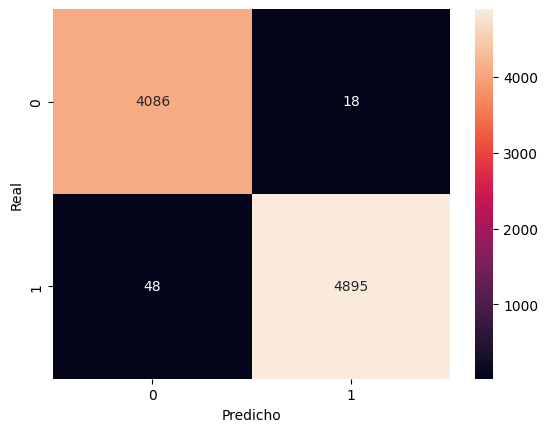

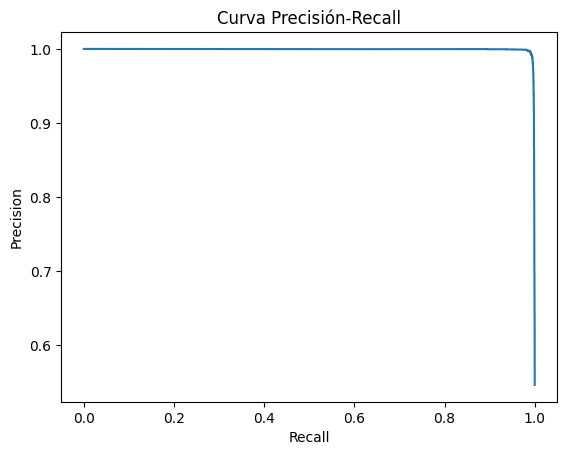

In [56]:
from sklearn.metrics import confusion_matrix, precision_recall_curve
import matplotlib.pyplot as plt
import seaborn as sns


y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.show()

precision, recall, thresholds = precision_recall_curve(y_test, y_proba)
plt.plot(recall, precision)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Curva Precisión-Recall')
plt.show()

In [6]:
import joblib

import pandas as pd
#joblib.dump(best_model, 'model.pkl')


loaded_model = joblib.load('model.pkl')


def predict_if_same_name(name1, name2, model=loaded_model, threshold=0.85):
    features = advanced_features(name1, name2)
    features_df = pd.DataFrame([features])
    
    features_df = features_df[X_train.columns]
    
    proba = model.predict_proba(features_df)[0][1]
    prediction = int(proba >= threshold)
    
    return {
        'prediction': prediction,
        'probability': proba,
        'features': features
    }


predict_if_same_name("Carlos Ruiz", "C. Ruiz")

NameError: name 'X_train' is not defined

In [1]:
name1="Danilo S Carvalho'"
name2="𝑎𝑏"
features = advanced_features(name1, name2)
features_df = pd.DataFrame([features])
proba = best_model.predict_proba(features_df)
prediction = best_model.predict(features_df)
    



NameError: name 'advanced_features' is not defined

In [129]:
proba

array([[0.02821328, 0.97178672]])

In [130]:
prediction

array([1])